# Cuaderno 8 — Pipeline Integrado de Seguridad con IA

Este cuaderno Final integra todos los componentes de la guía en un
**pipeline de seguridad end-to-end**:

```
┌─────────────────────────────────────────────────────────────┐
│                    PIPELINE DE SEGURIDAD IA                  │
│                                                             │
│  Datos  ──► Preprocesamiento ──► Detección de anomalías     │
│  de red                          (Isolation Forest)          │
│                                         │                   │
│  Archivos ──► Extracción PE ─────► Clasificación malware    │
│  PE                                (Random Forest)           │
│                                         │                   │
│                              ──► Motor de respuesta         │
│                                  (orquestación)             │
│                                         │                   │
│                              ──► Explicabilidad SHAP        │
│                                         │                   │
│                              ──► Monitoreo de deriva        │
└─────────────────────────────────────────────────────────────┘
```

**Objetivos:**
- Encapsular el pipeline en una clase reutilizable `PipelineSeguridad`.
- Persistir modelos con `joblib`.
- Demostrar análisis de tráfico + análisis de archivos en un único flujo.
- Generar un reporte de actividad final.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import shap
import os
import logging
from dataclasses import dataclass, field
from datetime import datetime
from typing import Optional

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy.stats import ks_2samp

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S"
)
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
print("Importaciones OK")

Importaciones OK


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


## 1. Generadores de datos sintéticos (reutilizados de cuadernos anteriores)

In [2]:
# ── Dataset de tráfico de red ───────────────────────────────────────────
def generar_trafico(n_normal=1000, n_anomalias=50, seed=42):
    rng = np.random.default_rng(seed)
    normal = pd.DataFrame({
        "bytes_sent":  rng.exponential(5_000,   n_normal),
        "bytes_recv":  rng.exponential(15_000,  n_normal),
        "duration":    rng.exponential(30,      n_normal),
        "src_port":    rng.integers(1024,65535, n_normal).astype(float),
        "dst_port":    rng.choice([80,443,22,8080,3306], n_normal).astype(float),
        "protocol":    rng.choice([6,17], n_normal).astype(float),
        "label": 0
    })
    anomalias = pd.DataFrame({
        "bytes_sent":  rng.exponential(500_000, n_anomalias),
        "bytes_recv":  rng.exponential(2_000,   n_anomalias),
        "duration":    rng.exponential(600,     n_anomalias),
        "src_port":    rng.integers(1024,65535, n_anomalias).astype(float),
        "dst_port":    rng.integers(1,1023,     n_anomalias).astype(float),
        "protocol":    rng.choice([6,17], n_anomalias).astype(float),
        "label": 1
    })
    return pd.concat([normal, anomalias], ignore_index=True).sample(frac=1, random_state=seed)

# ── Dataset de características PE ──────────────────────────────────────
def generar_malware(n_benign=1700, n_malicious=300, seed=42):
    rng = np.random.default_rng(seed)
    benign = pd.DataFrame({
        "entry_point":        rng.integers(4096,16384, n_benign).astype(float),
        "num_sections":       rng.integers(3,7,        n_benign).astype(float),
        "entropia_max":       rng.uniform(4.0,6.5,     n_benign),
        "num_importaciones":  rng.integers(20,150,     n_benign).astype(float),
        "num_dlls":           rng.integers(2,12,       n_benign).astype(float),
        "file_size":          rng.integers(50_000,2_000_000, n_benign).astype(float),
        "has_debug":          rng.integers(0,2,        n_benign).astype(float),
        "label": 0
    })
    malicious = pd.DataFrame({
        "entry_point":        rng.integers(0,4096,     n_malicious).astype(float),
        "num_sections":       rng.integers(8,20,       n_malicious).astype(float),
        "entropia_max":       rng.uniform(6.8,8.0,     n_malicious),
        "num_importaciones":  rng.integers(200,600,    n_malicious).astype(float),
        "num_dlls":           rng.integers(15,40,      n_malicious).astype(float),
        "file_size":          rng.integers(10_000,500_000, n_malicious).astype(float),
        "has_debug":          np.zeros(n_malicious, dtype=float),
        "label": 1
    })
    return pd.concat([benign, malicious], ignore_index=True).sample(frac=1, random_state=seed)

NET_FEATURES = ["bytes_sent","bytes_recv","duration","src_port","dst_port","protocol"]
PE_FEATURES  = ["entry_point","num_sections","entropia_max",
                "num_importaciones","num_dlls","file_size","has_debug"]

print("Generadores definidos.")

Generadores definidos.


## 2. Clase PipelineSeguridad

In [3]:
@dataclass
class ResultadoAnalisis:
    """Resultado de analizar un lote de datos a través del pipeline."""
    timestamp           : str
    n_flujos_analizados : int = 0
    n_anomalias_red     : int = 0
    n_archivos_analizados: int = 0
    n_malware_detectado  : int = 0
    alertas             : list = field(default_factory=list)


class PipelineSeguridad:
    """
    Pipeline integrado de ciberseguridad basado en IA.

    Módulos:
    - anomaly_detector : Isolation Forest para tráfico de red.
    - malware_clf      : Random Forest para análisis de archivos PE.
    - net_scaler       : Normalización de características de tráfico.
    """

    def __init__(self):
        self.net_scaler       = MinMaxScaler()
        self.anomaly_detector = IsolationForest(
            n_estimators=200, contamination=0.05,
            random_state=SEED, n_jobs=-1
        )
        self.malware_clf = RandomForestClassifier(
            n_estimators=200, n_jobs=-1, random_state=SEED
        )
        self._entrenado = False
        self._X_train_net_ref: Optional[np.ndarray] = None  # para monitoreo deriva

    # ── Entrenamiento ──────────────────────────────────────────────────
    def entrenar(
        self,
        df_trafico: pd.DataFrame,
        df_malware: pd.DataFrame,
        y_malware: pd.Series
    ) -> None:
        """Entrena ambos modelos con datos históricos etiquetados."""
        # Detector de anomalías en red
        X_net = self.net_scaler.fit_transform(df_trafico[NET_FEATURES])
        self.anomaly_detector.fit(X_net)
        self._X_train_net_ref = X_net
        logging.info(f"Isolation Forest entrenado ({len(X_net)} muestras).")

        # Clasificador de malware
        self.malware_clf.fit(df_malware[PE_FEATURES], y_malware)
        logging.info(f"Random Forest (malware) entrenado ({len(df_malware)} muestras).")

        self._entrenado = True

    # ── Análisis de tráfico ────────────────────────────────────────────
    def analizar_trafico(self, df: pd.DataFrame) -> pd.DataFrame:
        """Detecta flujos anómalos en un DataFrame de tráfico de red."""
        assert self._entrenado, "Debe entrenar el pipeline antes de usarlo."
        X = self.net_scaler.transform(df[NET_FEATURES])
        result = df.copy()
        result["anomalia"]    = self.anomaly_detector.predict(X)
        result["score"]       = self.anomaly_detector.decision_function(X)
        return result

    # ── Análisis de archivos ───────────────────────────────────────────
    def analizar_archivos(self, df: pd.DataFrame) -> pd.DataFrame:
        """Clasifica archivos PE como benignos o maliciosos."""
        assert self._entrenado, "Debe entrenar el pipeline antes de usarlo."
        result = df.copy()
        result["clasificacion"] = self.malware_clf.predict(df[PE_FEATURES])
        proba = self.malware_clf.predict_proba(df[PE_FEATURES])
        result["prob_malicioso"] = proba[:, 1]
        return result

    # ── Monitoreo de deriva ────────────────────────────────────────────
    def detectar_deriva(self, df_prod: pd.DataFrame,
                         umbral_p: float = 0.05) -> pd.DataFrame:
        """Test KS entre datos de entrenamiento y producción."""
        assert self._X_train_net_ref is not None
        X_prod = self.net_scaler.transform(df_prod[NET_FEATURES])
        filas = []
        for i, feat in enumerate(NET_FEATURES):
            stat, p = ks_2samp(self._X_train_net_ref[:, i], X_prod[:, i])
            filas.append({"caracteristica": feat, "ks": round(stat,4),
                          "p_valor": round(p,6), "deriva": p < umbral_p})
        return pd.DataFrame(filas)

    # ── Persistencia ──────────────────────────────────────────────────
    def guardar(self, ruta: str) -> None:
        joblib.dump(self, ruta)
        logging.info(f"Pipeline guardado en {ruta}")

    @staticmethod
    def cargar(ruta: str) -> "PipelineSeguridad":
        p = joblib.load(ruta)
        logging.info(f"Pipeline cargado desde {ruta}")
        return p

    # ── Análisis completo ─────────────────────────────────────────────
    def analizar_completo(
        self,
        df_trafico_live: pd.DataFrame,
        df_archivos_live: pd.DataFrame
    ) -> ResultadoAnalisis:
        """Ejecuta el pipeline completo y devuelve un resumen estructurado."""
        resultado = ResultadoAnalisis(timestamp=datetime.now().isoformat())

        # Tráfico de red
        df_red = self.analizar_trafico(df_trafico_live)
        result_red = df_red[df_red.anomalia == -1]
        resultado.n_flujos_analizados = len(df_red)
        resultado.n_anomalias_red     = len(result_red)
        if len(result_red) > 0:
            resultado.alertas.append(
                f"{len(result_red)} flujos anómalos detectados en red "
                f"(score min={result_red.score.min():.4f})"
            )

        # Archivos PE
        df_arch = self.analizar_archivos(df_archivos_live)
        malware_det = df_arch[df_arch.clasificacion == 1]
        resultado.n_archivos_analizados = len(df_arch)
        resultado.n_malware_detectado   = len(malware_det)
        if len(malware_det) > 0:
            top_p = malware_det.prob_malicioso.max()
            resultado.alertas.append(
                f"{len(malware_det)} archivo(s) malicioso(s) detectado(s) "
                f"(prob max={top_p:.4f})"
            )

        return resultado, df_red, df_arch

print("Clase PipelineSeguridad definida.")

Clase PipelineSeguridad definida.


## 3. Entrenamiento del pipeline

In [4]:
# Generar datos de entrenamiento
df_trafico_train = generar_trafico(n_normal=1000, n_anomalias=50, seed=SEED)
df_malware_train = generar_malware(n_benign=1700,  n_malicious=300, seed=SEED)
y_malware_train  = df_malware_train.pop("label")

# Instanciar y entrenar
pipeline = PipelineSeguridad()
pipeline.entrenar(
    df_trafico=df_trafico_train,
    df_malware=df_malware_train,
    y_malware=y_malware_train
)

# Guardar modelo
modelo_path = "/tmp/pipeline_seguridad.pkl"
pipeline.guardar(modelo_path)

20:58:45  INFO      Isolation Forest entrenado (1050 muestras).


20:58:45  INFO      Random Forest (malware) entrenado (2000 muestras).


20:58:46  INFO      Pipeline guardado en /tmp/pipeline_seguridad.pkl


## 4. Simulación de análisis en tiempo real

In [5]:
# Cargar pipeline desde disco (simula un servicio que lo carga al inicio)
pipeline_prod = PipelineSeguridad.cargar(modelo_path)

# Datos "en vivo" (nuevo lote de tráfico y archivos)
df_trafico_live  = generar_trafico(n_normal=200, n_anomalias=15, seed=SEED+10)
df_archivos_live = generar_malware(n_benign=80,  n_malicious=20, seed=SEED+10)
df_archivos_live.drop("label", axis=1, inplace=True, errors="ignore")

# Análisis completo
resultado, df_red_analizado, df_arch_analizado = pipeline_prod.analizar_completo(
    df_trafico_live, df_archivos_live
)

print("=" * 60)
print(f"REPORTE DE SEGURIDAD — {resultado.timestamp}")
print("=" * 60)
print(f"  Flujos de red analizados   : {resultado.n_flujos_analizados}")
print(f"  Anomalías en red           : {resultado.n_anomalias_red}")
print(f"  Archivos analizados        : {resultado.n_archivos_analizados}")
print(f"  Malware detectado          : {resultado.n_malware_detectado}")
print()
if resultado.alertas:
    print("  ALERTAS:")
    for alerta in resultado.alertas:
        print(f"    [!] {alerta}")
else:
    print("  Sin alertas activas.")

20:58:46  INFO      Pipeline cargado desde /tmp/pipeline_seguridad.pkl


REPORTE DE SEGURIDAD — 2026-05-05T20:58:46.134996
  Flujos de red analizados   : 215
  Anomalías en red           : 17
  Archivos analizados        : 100
  Malware detectado          : 20

  ALERTAS:
    [!] 17 flujos anómalos detectados en red (score min=-0.1340)
    [!] 20 archivo(s) malicioso(s) detectado(s) (prob max=1.0000)


## 5. Monitoreo de deriva de datos en producción

Test de deriva (KS):
caracteristica     ks  p_valor  deriva
    bytes_sent 0.1004 0.050772   False
    bytes_recv 0.0241 0.999868   False
      duration 0.0789 0.203771   False
      src_port 0.0823 0.167058   False
      dst_port 0.0381 0.948139   False
      protocol 0.0364 0.964134   False


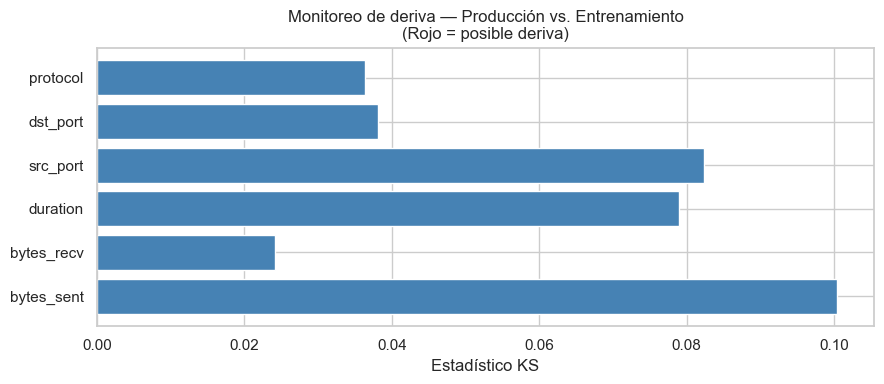

In [6]:
df_deriva = pipeline_prod.detectar_deriva(df_trafico_live)

print("Test de deriva (KS):")
print(df_deriva.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colores = ["tomato" if d else "steelblue" for d in df_deriva.deriva]
ax.barh(df_deriva.caracteristica, df_deriva.ks, color=colores)
ax.set_xlabel("Estadístico KS")
ax.set_title("Monitoreo de deriva — Producción vs. Entrenamiento\n(Rojo = posible deriva)")
plt.tight_layout()
plt.show()

## 6. Dashboard de resumen visual

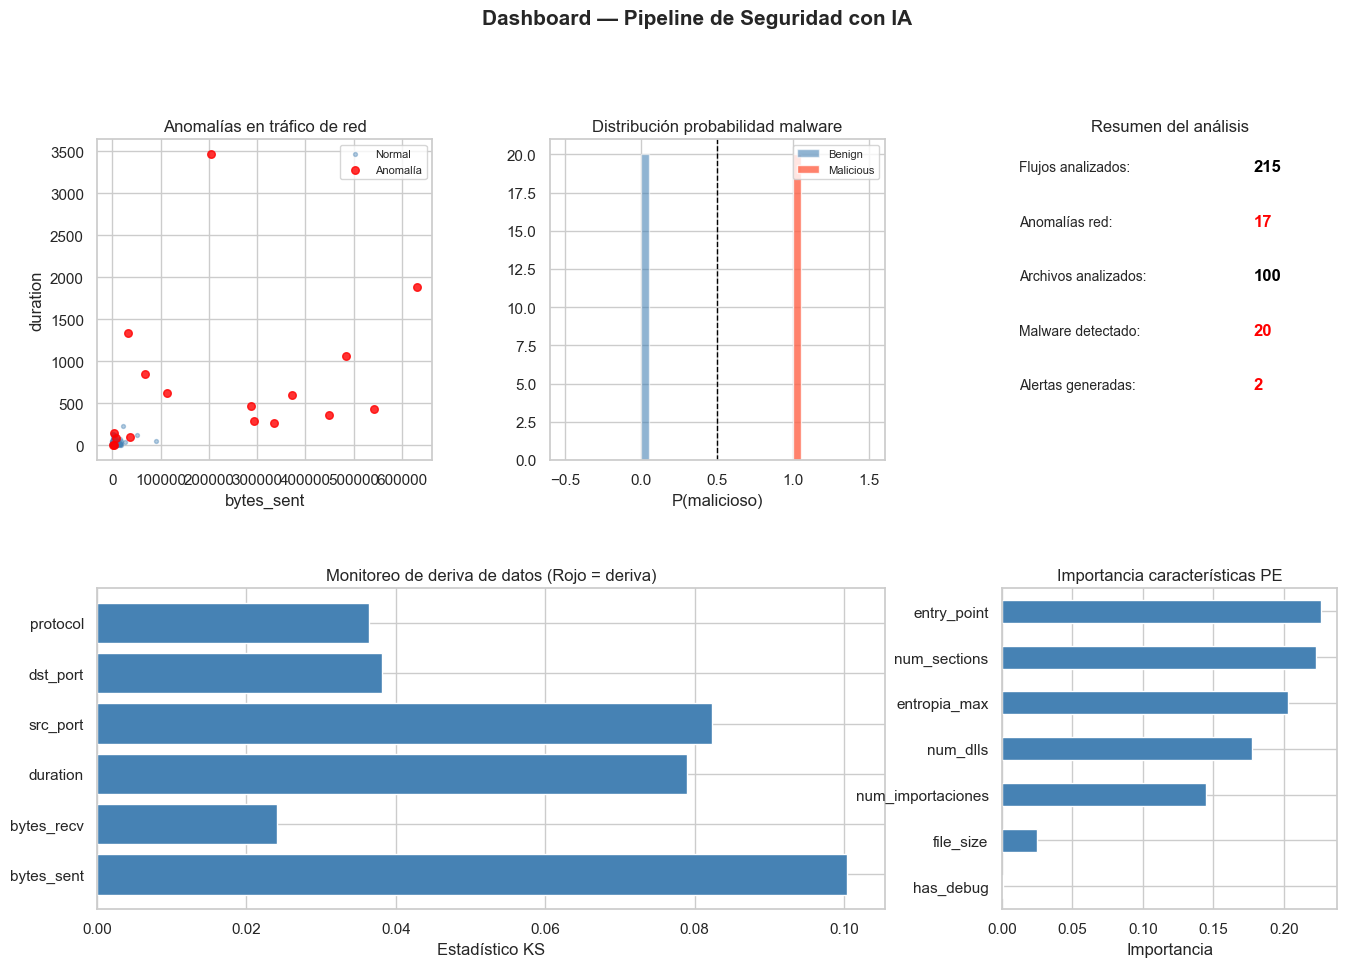

Dashboard guardado en /tmp/security_dashboard.png


In [7]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Panel 1: Anomalías en red ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
normal_mask = df_red_analizado.anomalia == 1
anom_mask   = df_red_analizado.anomalia == -1
ax1.scatter(df_red_analizado[normal_mask].bytes_sent,
            df_red_analizado[normal_mask].duration,
            s=8, c="steelblue", alpha=0.4, label="Normal")
ax1.scatter(df_red_analizado[anom_mask].bytes_sent,
            df_red_analizado[anom_mask].duration,
            s=30, c="red", alpha=0.8, label="Anomalía")
ax1.set_title("Anomalías en tráfico de red")
ax1.set_xlabel("bytes_sent")
ax1.set_ylabel("duration")
ax1.legend(fontsize=8)

# ── Panel 2: Distribución de probabilidad de malware ──────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df_arch_analizado[df_arch_analizado.clasificacion == 0].prob_malicioso,
         bins=20, alpha=0.6, color="steelblue", label="Benign", density=True)
ax2.hist(df_arch_analizado[df_arch_analizado.clasificacion == 1].prob_malicioso,
         bins=20, alpha=0.8, color="tomato",    label="Malicious", density=True)
ax2.axvline(0.5, ls="--", color="black", lw=1)
ax2.set_title("Distribución probabilidad malware")
ax2.set_xlabel("P(malicioso)")
ax2.legend(fontsize=8)

# ── Panel 3: Resumen numérico ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis("off")
metricas = [
    ("Flujos analizados",          resultado.n_flujos_analizados),
    ("Anomalías red",              resultado.n_anomalias_red),
    ("Archivos analizados",        resultado.n_archivos_analizados),
    ("Malware detectado",          resultado.n_malware_detectado),
    ("Alertas generadas",          len(resultado.alertas)),
]
y_pos = 0.9
for label, valor in metricas:
    color = "red" if ("Anomalías" in label or "Malware" in label or "Alertas" in label) and valor > 0 else "black"
    ax3.text(0.05, y_pos, f"{label}:", fontsize=10, transform=ax3.transAxes)
    ax3.text(0.75, y_pos, str(valor), fontsize=12, fontweight="bold",
             color=color, transform=ax3.transAxes)
    y_pos -= 0.17
ax3.set_title("Resumen del análisis")

# ── Panel 4: Deriva de datos ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
colores = ["tomato" if d else "steelblue" for d in df_deriva.deriva]
ax4.barh(df_deriva.caracteristica, df_deriva.ks, color=colores)
ax4.set_xlabel("Estadístico KS")
ax4.set_title("Monitoreo de deriva de datos (Rojo = deriva)")

# ── Panel 5: Importancia de características malware ───────────────────
ax5 = fig.add_subplot(gs[1, 2])
importancias = pd.Series(
    pipeline_prod.malware_clf.feature_importances_, index=PE_FEATURES
).sort_values()
importancias.plot(kind="barh", ax=ax5, color="steelblue")
ax5.set_title("Importancia características PE")
ax5.set_xlabel("Importancia")

fig.suptitle("Dashboard — Pipeline de Seguridad con IA",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig("/tmp/security_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard guardado en /tmp/security_dashboard.png")

## 7. Explicabilidad del modelo de malware con SHAP

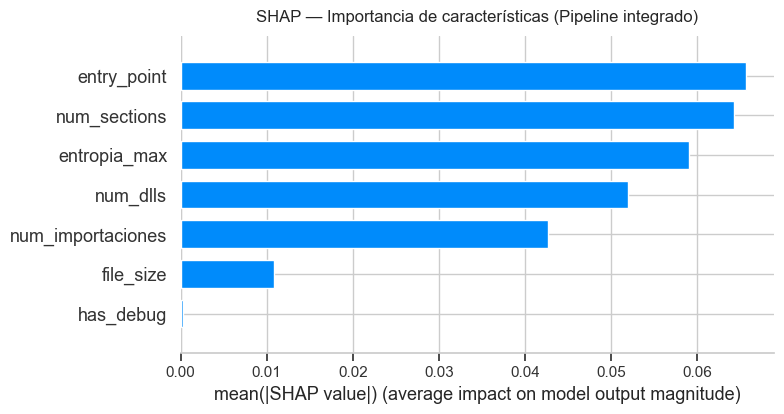


✓ Cuaderno 8 completado.

Resumen final:
  - Pipeline serializado en: /tmp/pipeline_seguridad.pkl
  - Dashboard guardado en:   /tmp/security_dashboard.png


In [8]:
# Calcular SHAP para los archivos analizados
X_arch_live = df_archivos_live[PE_FEATURES]

explainer   = shap.TreeExplainer(pipeline_prod.malware_clf)
shap_values = explainer.shap_values(X_arch_live)
shap_mal    = shap_values[1]   # clase malicious

plt.figure(figsize=(9, 4))
shap.summary_plot(shap_mal, X_arch_live, plot_type="bar", show=False)
plt.title("SHAP — Importancia de características (Pipeline integrado)", pad=10)
plt.tight_layout()
plt.show()

print("\n✓ Cuaderno 8 completado.")
print("\nResumen final:")
print(f"  - Pipeline serializado en: {modelo_path}")
print(f"  - Dashboard guardado en:   /tmp/security_dashboard.png")